### Import dependencies

In [1]:
from astroquery.simbad import Simbad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy import constants as c

import sys
sys.path.append('../')
from Functions.queryGrid import *
import gdr3bcg.bcg as bcg

The archive is unstable and may perform below expectations. Please avoid launching intense Python query showers. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the recent infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


### Download Data

In [3]:
# Import data
data = pd.read_csv('Target EBs Data.txt', sep=",")
data['Target'] = data['Target'].astype(str).str[4:]

# Swap values so primary is always 1, secondary is always 2
mask = data['Depth1'] < data['Depth2']

data.loc[mask, ['Depth1', 'Depth2']] = data.loc[mask, ['Depth2', 'Depth1']].values
data.loc[mask, ['Width1', 'Width2']] = data.loc[mask, ['Width2', 'Width1']].values

data.loc[mask, ['A1 Error', 'A2 Error']] = data.loc[mask, ['A2 Error', 'A1 Error']].values
data.loc[mask, ['D1 Error', 'D2 Error']] = data.loc[mask, ['D2 Error', 'D1 Error']].values

# Calculate differences
data['Depth_diff'] = data['Depth1'] - data['Depth2']
data['Width_diff'] = data['Width1'] - data['Width2']

data

,Index,Target,Period,P Error,Width1,D1 Error,Width2,D2 Error,Depth1,A1 Error,Depth2,A2 Error,Depth_diff,Width_diff
0,10,364325969,0.419969,0.000505,0.290700,0.002186,0.271385,0.002067,0.280612,0.001074,0.252116,0.001046,0.028497,0.019315
1,15,140757590,0.418107,0.000505,0.290928,0.002647,0.289017,0.002844,0.232838,0.001196,0.204145,0.001194,0.028693,0.001911
2,30,177258700,0.687983,0.001717,0.279148,0.002482,0.295641,0.002888,0.274425,0.001238,0.240436,0.001202,0.033989,-0.016493
3,62,349480507,3.124534,0.010000,0.088573,0.000387,0.088678,0.000264,0.381629,0.000552,0.381090,0.000510,0.000539,-0.000105
4,75,33715938,2.876839,0.010000,0.072133,0.000853,0.070855,0.000567,0.364874,0.001583,0.349181,0.001420,0.015694,0.001278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,919,286566392,1.446364,0.007778,0.132649,0.000761,0.122078,0.001164,0.339543,0.000978,0.327709,0.001137,0.011834,0.010571
145,932,53708889,8.460484,0.010000,0.045655,0.000030,0.043480,0.000030,0.475823,0.000141,0.471642,0.000144,0.004182,0.002175
146,959,21174723,0.464018,0.000101,0.094390,0.002508,0.097415,0.001709,0.629589,0.005986,0.615648,0.004909,0.013941,-0.003025
147,969,348517784,4.221258,0.010000,0.050650,0.000157,0.047813,0.000191,0.389443,0.000537,0.368525,0.000718,0.020918,0.002837


In [4]:
gaiaQuery = queryGaia(data['Target'].to_list(), DR=3)
gaiaQuery = gaiaQuery.merge(data[['Target', 'Period']], left_on='TIC_id', right_on='Target', how='left')
# gaiaQuery['Expected Mag'] = 5 + gaiaQuery['Gaia3_G'] - 5*np.log10(gaiaQuery['Gaia3_dist'])

gaiaQuery['bp_rp'] -= gaiaQuery['ext']
gaiaQuery = gaiaQuery[gaiaQuery['Gaia3_T'].between(4440, 6670, inclusive='both')].reset_index(drop=True)
gaiaQuery = Gaia3ToJohnson(gaiaQuery)
gaiaQuery

,Gaia3_id,TIC_id,Gaia3_dist,Gaia3_parallax,Gaia3_G,Gaia3_T,bp_rp,ext,bp_rp_err,Target,Period,b_v,b_v_err
0,189291376380052992,239052494,126.471962,7.906891,7.856887,6163.878418,0.647253,0.1055,0.003642,239052494,7.702470,0.552158,0.065980
1,189506567123759360,67296459,841.457761,1.188414,14.115475,6118.546387,0.666016,0.0009,0.020471,67296459,0.642118,0.568876,0.068386
2,266707921371366912,320947341,144.528050,6.919072,10.105134,5706.697266,0.801564,0.1196,0.002217,320947341,2.067000,0.691028,0.065931
3,329369634497774336,63623869,294.790467,3.392240,12.296331,5778.194824,0.776479,0.2397,0.025555,63623869,1.526598,0.668286,0.069847
4,374473598629517056,352378412,192.836153,5.185750,10.751903,5342.168945,0.915786,0.1805,0.028428,352378412,0.676000,0.794895,0.070795
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,5786099578043436928,418532689,286.697011,3.488003,13.844475,4474.629395,1.338388,0.3352,0.034421,418532689,0.380814,1.173519,0.072460
63,5912127520668348032,306272819,513.885975,1.945957,12.112444,5709.367188,0.785526,0.0298,0.001207,306272819,2.546000,0.676483,0.065909
64,6169396512667865216,405533713,86.689136,11.535471,9.713539,5602.570801,0.858129,0.1229,0.032978,405533713,0.279993,0.742430,0.072407
65,6181063980305593472,124205037,140.796523,7.102448,10.251201,5774.218262,0.784552,0.1331,0.030366,124205037,0.332935,0.675601,0.071416


### Retrieving spectral types

In [5]:
def querySimbad(tic_ids):
    Simbad.add_votable_fields('sp_type')
    
    formatted_ids = [f'TIC {int(tid)}' for tid in tic_ids]
    results = Simbad.query_objects(formatted_ids)
    
    if results is None:
        print("No results found")
        return None
    
    df = results.to_pandas()
    df.insert(1, 'TIC_id', tic_ids)
    
    df['sp_type'] = df['sp_type'].replace(r'^\s*$', np.nan, regex=True)
    df = df.dropna(subset=['sp_type'])
            
    return df[['main_id', 'TIC_id', 'sp_type']]

spectral_df = querySimbad(gaiaQuery['TIC_id'].to_list())
spectral_df['T_eff'] = gaiaQuery['Gaia3_T']
spectral_df

,main_id,TIC_id,sp_type,T_eff
0,HD 37071,239052494,G0,6163.878418
1,V* V363 Aur,67296459,K0V,6118.546387
5,V* V654 Cas,417585921,B3,5598.238770
6,V* KL Per,301909087,A2,6644.770020
8,V* V505 Per,348517784,F5,6480.340332
10,V* DU Leo,233635280,G0(N),5881.871094
11,V* GX Gem,240154683,G5,5826.254395
12,RX J0612.3+5812,322549898,G7,5757.745605
14,V* RS CVn,180570279,F6IV+G8IV,6238.561523
15,V* EN CVn,288434781,F6,6034.619629


### Fitting to best config

In [6]:
all_grids = queryPrimary(gaiaQuery, filepath='binarystargrid.db')

final_results = []

for target_id, grid in all_grids.items():
    obs = data[data['Target'] == target_id].iloc[0]
    best_fit = querySecondary(pd.DataFrame(grid), obs['Depth_diff'], obs['Width_diff'], width_format='absolute', primary_width=obs['Width1'])
    best_fit['Target'] = target_id
    final_results.append(best_fit)
    
df_grid = pd.concat(final_results).reset_index(drop=True)
df_grid['Period'] = gaiaQuery['Period']
df_grid['Dist'] = gaiaQuery['Gaia3_dist']
df_grid['Actual SpT'] = spectral_df['sp_type']
df_grid['b_v'] = gaiaQuery['b_v']
df_grid['b_v_err'] = gaiaQuery['b_v_err']
df_grid['Gaia3_T'] = gaiaQuery['Gaia3_T']

df_grid = df_grid.drop(columns=['Primary B-V', 'Primary BP-RP', 'Depth Difference', 'Width Difference']).reset_index(drop=True)
df_grid = df_grid[df_grid['Primary SpT'] == df_grid['Secondary SpT']].reset_index(drop=True)

# Temp calculations for comparison
df_grid['Ballesteros T'] = 4600 * ((0.92 * df_grid['b_v'] + 1.7)**-1 + (0.92 * df_grid['b_v'] + 0.62)**-1)
df_grid['Ballesteros T_err'] = (4600 * 0.92 * ((0.92 * df_grid['b_v'] + 1.7)**-2 + (0.92 * df_grid['b_v'] + 0.62)**-2)) * df_grid['b_v_err']

# casgrandePoly = np.poly1d([-0.0060, 0.4809, 0.5665])
# df_grid['Casgrande T'] = 5040 * (0.5665 + 0.4809 * df_grid['b_v'] - 0.0060 * df_grid['b_v']**2)**-1
# df_grid['Huang T'] = 5040 * (0.63421 + 0.30538 * df_grid['b_v'] + 0.12308 * df_grid['b_v']**2)**-1

df_grid

,Primary SpT,Primary T,Primary R,Primary M,Secondary SpT,Secondary T,Secondary R,Secondary M,Target,Period,Dist,Actual SpT,b_v,b_v_err,Gaia3_T,Ballesteros T,Ballesteros T_err
0,F9,6050.0,1.167,1.130,F9,6050.0,1.167,1.130,67296459,0.642118,841.457761,K0V,0.568876,0.068386,6118.546387,6092.142424,279.928390
1,G4,5680.0,0.991,0.985,G4,5680.0,0.991,0.985,63623869,1.526598,294.790467,NaN,0.668286,0.069847,5778.194824,5712.421561,249.020717
2,G9,5380.0,0.853,0.900,G9,5380.0,0.853,0.900,352378412,0.676000,192.836153,NaN,0.794895,0.070795,5342.168945,5296.111537,214.757742
3,F5,6550.0,1.473,1.330,F5,6550.0,1.473,1.330,301909087,4.446054,645.288526,A2,0.442319,0.065918,6644.770020,6662.624103,327.364329
4,G8,5480.0,0.914,0.940,G8,5480.0,0.914,0.940,117175528,2.254835,642.555887,NaN,0.729442,0.066046,5461.954590,5502.928630,217.397528
5,F5,6550.0,1.473,1.330,F5,6550.0,1.473,1.330,418244848,8.642211,277.526093,NaN,0.458997,0.065902,6598.125488,6580.898398,318.651818
6,G4,5680.0,0.991,0.985,G4,5680.0,0.991,0.985,322549898,1.794912,184.846226,G7,0.669016,0.066148,5757.745605,5709.822464,235.605002
7,G7,5550.0,0.927,0.950,G7,5550.0,0.927,0.950,310169616,0.411889,474.542352,NaN,0.716271,0.078886,6127.481445,5546.649487,264.084013
8,G0,5930.0,1.100,1.060,G0,5930.0,1.100,1.060,288434781,6.333464,278.778635,F6,0.597745,0.065905,6034.619629,5976.386286,258.870736
9,F9,6050.0,1.167,1.130,F9,6050.0,1.167,1.130,441687696,2.225326,808.544438,F5,0.553606,0.065912,6242.285645,6155.349178,275.861190


### Geometry calculations to final luminosity

In [7]:
def calculateMass(df):
    # Coefficents
    a = -0.964
    b = 3.475e-4 
    
    # Systematics
    a_err = 0.003
    b_err = 0.006e-4 
    
    T = df['Ballesteros T']
    T_err = df['Ballesteros T_err']
    
    df['M'] = a + b * T
    df['M_err'] = np.sqrt(a_err**2 + (T * b_err)**2 + (b * T_err)**2) # Errors propagated via derivative
    return df

In [8]:
# Velocity (+ SMA) calculation
def calculateVel(df):
    P_sec = df['Period'] * 24 * 60**2
    
    # Semi major axis calc
    df['a'] = ((c.GM_sun * df['M']) / (2 * np.pi**2) * (P_sec)**2)**(1/3)
    
    # SMA Error handling
    rel_err_M = df['M_err'] / df['M']
    rel_err_P = df['P Error'] / df['Period'] # Ensure units match (days/days)
    
    rel_err_a = np.sqrt(( (1/3) * rel_err_M )**2 + ( (2/3) * rel_err_P )**2)
    
    # Convert relative error back to absolute error
    df['a_err'] = rel_err_a * df['a']
    
    # -------------------
    # Vel calc
    df['v'] = 2 * np.pi * df['a'] / P_sec
    
    rel_err_v = np.sqrt(( (1/3) * rel_err_M )**2 + ( (1/3) * rel_err_P )**2)
    df['v_err'] = rel_err_v * df['v']
    
    return df

In [9]:
def calculateRadius(df):
    # Period conversion
    width1_sec = df['Width1'] * 24 * 3600
    width2_sec = df['Width2'] * 24 * 3600
    
    # Radius calculation
    df['R1'] = width1_sec * df['v'] / 2
    df['R2'] = width2_sec * df['v'] / 2
    
    # Error handling
    rel_err_w1 = df['D1 Error'] / df['Width1']
    rel_err_w2 = df['D2 Error'] / df['Width2']
    rel_err_v = df['v_err'] / df['v']
    
    rel_err_r1 = np.sqrt(rel_err_w1**2 + rel_err_v**2)
    rel_err_r2 = np.sqrt(rel_err_w2**2 + rel_err_v**2)
    
    df['R1_err'] = df['R1'] * rel_err_r1
    df['R2_err'] = df['R2'] * rel_err_r2
    
    return df

In [10]:
def calculateLuminosity(df):
    # Luminosity Calculation
    df['L1'] = 4 * np.pi * df['R1']**2 * c.sigma_sb * df['Ballesteros T']**4 # luminonisty in W
    df['L2'] = 4 * np.pi * df['R2']**2 * c.sigma_sb * df['Ballesteros T']**4
    
    # Error propagation
    rel_err_r1 = df['R1_err'] / df['R1']
    rel_err_r2 = df['R2_err'] / df['R2']
    rel_err_t = df['Ballesteros T_err'] / df['Ballesteros T']
    
    rel_err_L1 = np.sqrt((2 * rel_err_r1)**2 + (4 * rel_err_t)**2)
    rel_err_L2 = np.sqrt((2 * rel_err_r2)**2 + (4 * rel_err_t)**2)
    
    df['L1_err'] = rel_err_L1 * df['L1']
    df['L2_err'] = rel_err_L2 * df['L2']
    
    # Magnitude calculation + error
    df['Calc_Mag'] = 4.74 - 2.5 * np.log10((df['L1'] + df['L2'])/c.L_sun)
    df['Calc_Mag_err'] = np.sqrt(rel_err_L1**2 + rel_err_L2**2) / (np.log(10) * (df['L1'] + df['L2'])/c.L_sun)
    
    return df

In [11]:
# Create table
df_lum = df_grid[['Target', 'Dist', 'Period', 'b_v', 'Ballesteros T', 'Ballesteros T_err']].copy()
df_lum = df_lum.merge(data[['Target', 'P Error', 'Depth1', 'Depth2', 'A1 Error', 'Width1', 'D1 Error', 'Width2', 'D2 Error']], on='Target', how='left')

df_lum = calculateMass(df_lum)
df_lum = calculateVel(df_lum)
df_lum = calculateRadius(df_lum)
df_lum = calculateLuminosity(df_lum)

df_lum
# df_lum['a'] = ((c.GM_sun * df_lum['M']) / (2 * np.pi**2) * (df_lum['Period'] * 24 * 60**2)**2)**(1/3) # semi-major axis in metres
# df_lum['v'] = 2 * np.pi * df_lum['a'] / (df_lum['Period'] * 24 * 60**2) # velocity in m/s

# df_lum['R1'] = (df_lum['Width1'] * 24 * 60**2) * df_lum['v'] / 2 # radii in m
# df_lum['R2'] = (df_lum['Width2'] * 24 * 60**2) * df_lum['v'] / 2

# df_lum['L1'] = 4 * np.pi * df_lum['R1']**2 * c.sigma_sb * df_lum['Ballesteros T']**4 # luminonisty in W
# df_lum['L2'] = 4 * np.pi * df_lum['R2']**2 * c.sigma_sb * df_lum['Ballesteros T']**4

# df_lum['Calc_Mag'] = 4.74 - 2.5 * np.log10((df_lum['L1'] + df_lum['L2'])/c.L_sun) # scaled from L/L_odon

,Target,Dist,Period,b_v,Ballesteros T,Ballesteros T_err,P Error,Depth1,Depth2,A1 Error,...,R1,R2,R1_err,R2_err,L1,L2,L1_err,L2_err,Calc_Mag,Calc_Mag_err
0,67296459,841.457761,0.642118,0.568876,6092.142424,279.928390,0.000707,0.354764,0.344275,0.003121,...,1.810961e+09,1.814700e+09,6.200988e+07,6.177557e+07,3.218993e+27,3.232298e+27,6.313741e+26,6.335342e+26,1.673313,0.007146
1,63623869,294.790467,1.526598,0.668286,5712.421561,249.020717,0.010000,0.335244,0.312996,0.002342,...,6.310612e+08,6.759865e+08,2.327642e+07,2.030479e+07,3.021660e+26,3.467198e+26,5.721022e+25,6.394545e+25,4.167009,0.067718
2,352378412,192.836153,0.676000,0.794895,5296.111537,214.757742,0.001515,0.331404,0.317777,0.000542,...,2.762667e+09,3.827168e+09,7.918298e+07,1.100495e+08,4.278653e+27,8.211174e+27,7.360644e+26,1.413093e+27,0.956039,0.003239
3,301909087,645.288526,4.446054,0.442319,6662.624103,327.364329,0.010000,0.443183,0.439449,0.000168,...,6.557649e+08,6.518713e+08,1.843608e+07,1.832445e+07,6.038085e+26,5.966596e+26,1.234322e+26,1.219697e+26,3.499053,0.040036
4,117175528,642.555887,2.254835,0.729442,5502.928630,217.397528,0.010000,0.366232,0.355921,0.000219,...,1.152100e+09,1.242097e+09,3.073222e+07,3.313221e+07,8.673162e+26,1.008111e+27,1.446561e+26,1.681384e+26,3.014679,0.020909
5,418244848,277.526093,8.642211,0.458997,6580.898398,318.651818,0.010000,0.340061,0.333651,0.004446,...,1.688154e+08,1.682438e+08,6.553986e+06,7.277578e+06,3.808783e+25,3.783036e+25,7.947688e+24,8.024802e+24,6.496565,0.651597
6,322549898,184.846226,1.794912,0.669016,5709.822464,235.605002,0.010000,0.353941,0.344451,0.000282,...,7.222406e+08,7.268638e+08,1.943660e+07,1.956131e+07,3.950716e+26,4.001457e+26,6.858700e+25,6.946800e+25,3.946215,0.051328
7,310169616,474.542352,0.411889,0.716271,5546.649487,264.084013,0.000707,0.350571,0.344189,0.001511,...,4.361161e+09,4.357672e+09,1.440541e+08,1.436053e+08,1.282770e+28,1.280718e+28,2.585786e+27,2.581009e+27,0.175351,0.001849
8,288434781,278.778635,6.333464,0.597745,5976.386286,258.870736,0.010000,0.503696,0.468884,0.000294,...,2.382732e+08,2.457335e+08,6.438968e+06,6.649358e+06,5.160916e+25,5.489147e+25,9.366873e+24,9.963772e+24,6.129049,0.400694
9,441687696,808.544438,2.225326,0.553606,6155.349178,275.861190,0.010000,0.343597,0.330430,0.000451,...,1.102473e+09,1.104079e+09,3.021609e+07,3.026936e+07,1.243277e+27,1.246902e+27,2.330639e+26,2.337495e+26,2.706853,0.017699


In [12]:
# df_tess = pd.read_csv('TESS EBS Catalogue.csv', delimiter=',', header=0, usecols=['tess_id', 'Tmag'], dtype={'tess_id': str})
# df_tess.columns = ['Target', 'Tmag']

df = df_lum[['Target', 'Dist', 'Ballesteros T', 'Ballesteros T_err', 'Period', 'P Error', 'Calc_Mag', 'Calc_Mag_err', 'Width1', 'D1 Error', 'Width2', 'D2 Error']].copy()
df = df.merge(gaiaQuery[['TIC_id', 'Gaia3_G', 'Gaia3_T', 'Gaia3_dist', 'b_v']], left_on='Target', right_on='TIC_id', how='left')
# df = df.merge(df_tess, on='Target', how='left')

table=bcg.BolometryTable()
df['bc_G'] = df['Gaia3_T'].apply(lambda x: table.computeBc([x, 4.4, 0, 0]))
df['Actual_Mag'] = df['Gaia3_G'] + df['bc_G']

df['calc_d'] = 10**((df['Actual_Mag'] - df['Calc_Mag'] + 5) / 5)
df['calc_d_err'] = np.log(10)/5 * df['calc_d'] * df['Calc_Mag_err']
df['expected_mag'] = 5 + df['Actual_Mag'] - 5*np.log10(df['Gaia3_dist'])
df['depth'] = df_lum['Depth1']
df['depth_err'] = df_lum['A1 Error']
df['diff'] = df['Calc_Mag'] - df['expected_mag']

df = df[['Target', 'Dist', 'calc_d', 'calc_d_err', 'expected_mag', 'Calc_Mag', 'Calc_Mag_err', 'Ballesteros T', 'Ballesteros T_err', 'Gaia3_T', 'b_v', 'diff', 'Period', 'P Error', 'depth', 'depth_err', 'Width1', 'Width2', 'D1 Error', 'D2 Error']]
df

/home/noah/miniconda3/envs/mPhysPrj/lib/python3.13/site-packages/gdr3bcg-1.1-py3.13.egg/gdr3bcg/bcg.py:43: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  table=pd.read_table(file, delim_whitespace=True, names=["teff", "logg","metal","alpha","bc"],dtype={'teff':np.float64,'logg':np.float64,'metal':np.float64,'alpha':np.float64,'bc':np.float64})


,Target,Dist,calc_d,calc_d_err,expected_mag,Calc_Mag,Calc_Mag_err,Ballesteros T,Ballesteros T_err,Gaia3_T,b_v,diff,Period,P Error,depth,depth_err,Width1,Width2,D1 Error,D2 Error
0,67296459,841.457761,3211.806515,10.568965,4.581899,1.673313,0.007146,6092.142424,279.928390,6118.546387,0.568876,-2.908585,0.642118,0.000707,0.354764,0.003121,0.128573,0.128838,0.002505,0.002465
1,63623869,294.790467,438.402045,13.671793,5.028805,4.167009,0.067718,5712.421561,249.020717,5778.194824,0.668286,-0.861796,1.526598,0.010000,0.335244,0.002342,0.062270,0.066702,0.001468,0.000658
2,352378412,192.836153,927.512488,1.383462,4.366695,0.956039,0.003239,5296.111537,214.757742,5342.168945,0.794895,-3.410657,0.676000,0.001515,0.331404,0.000542,0.218637,0.302882,0.000773,0.001279
3,301909087,645.288526,284.183777,5.239536,1.718280,3.499053,0.040036,6662.624103,327.364329,6644.770020,0.442319,1.780773,4.446054,0.010000,0.443183,0.000168,0.084167,0.083667,0.000076,0.000066
4,117175528,642.555887,397.443094,3.826929,1.971499,3.014679,0.020909,5502.928630,217.397528,5461.954590,0.729442,1.043180,2.254835,0.010000,0.366232,0.000219,0.132698,0.143064,0.000173,0.000185
5,418244848,277.526093,39.882342,11.967551,2.283949,6.496565,0.651597,6580.898398,318.651818,6598.125488,0.458997,4.212616,8.642211,0.010000,0.340061,0.004446,0.027233,0.027141,0.000734,0.000896
6,322549898,184.846226,234.407627,5.540758,4.462021,3.946215,0.051328,5709.822464,235.605002,5757.745605,0.669016,-0.515806,1.794912,0.010000,0.353941,0.000282,0.075241,0.075722,0.000129,0.000130
7,310169616,474.542352,2714.003915,2.310393,3.962029,0.175351,0.001849,5546.649487,264.084013,6127.481445,0.716271,-3.786677,0.411889,0.000707,0.350571,0.001511,0.283508,0.283281,0.002540,0.002457
8,288434781,278.778635,85.608890,15.797087,3.565346,6.129049,0.400694,5976.386286,258.870736,6034.619629,0.597745,2.563703,6.333464,0.010000,0.503696,0.000294,0.036711,0.037861,0.000051,0.000074
9,441687696,808.544438,681.781447,5.557049,2.336560,2.706853,0.017699,6155.349178,275.861190,6242.285645,0.553606,0.370294,2.225326,0.010000,0.343597,0.000451,0.117707,0.117878,0.000323,0.000333


### Plots

In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.optimize import curve_fit
from astropy import stats

plt.rcParams.update({'font.size' : 16})

Bias: -0.487 (+0.544 / -0.205)
Clean: 34


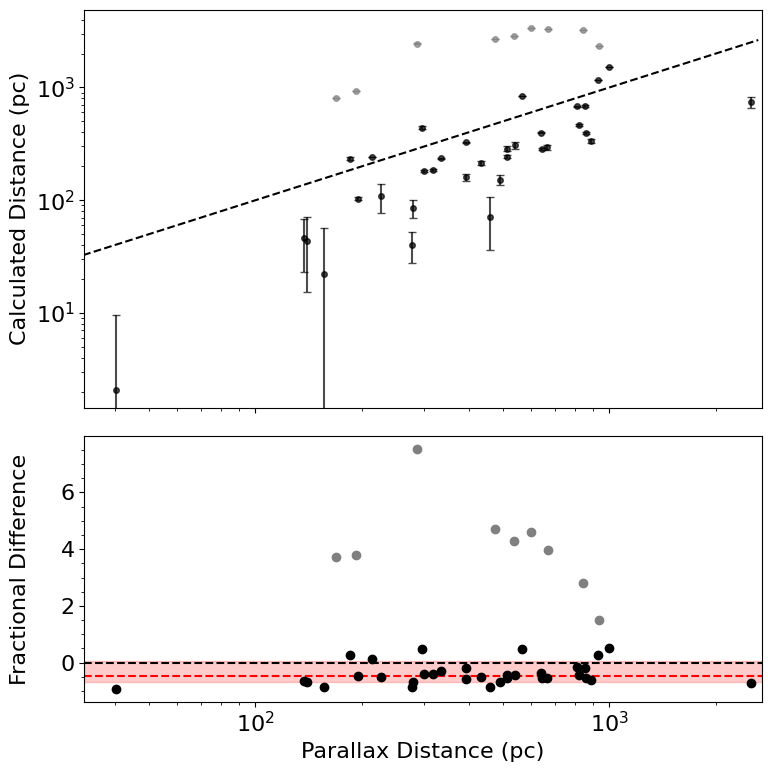

In [29]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, gridspec_kw={'height_ratios': [3,2]})
fig.subplots_adjust(hspace=0.00)

dist_diff = (df['calc_d'] - df['Dist']) / df['Dist']
filtered = stats.sigma_clip(dist_diff, sigma=4, cenfunc='median', stdfunc='mad_std')
outliers = filtered.mask

clean = df[~outliers]
outliers = df[outliers]

ax1.errorbar(
    x=clean['Dist'],
    y=clean['calc_d'],
    yerr=clean['calc_d_err'],
    fmt='o',            # 'o' creates a scatter plot (points), rather than a line
    markersize=4,       # Adjust point size
    capsize=3,           # Adds horizontal 'caps' to the error bars
    color='black',
    ecolor='black',      # Color of the error bars
    alpha=0.7,          # Transparency to help see overlapping points
    label='Distance Difference'
)

ax1.errorbar(
    x=outliers['Dist'],
    y=outliers['calc_d'],
    yerr=outliers['calc_d_err'],
    fmt='o',            # 'o' creates a scatter plot (points), rather than a line
    markersize=4,       # Adjust point size
    capsize=3,           # Adds horizontal 'caps' to the error bars
    color='grey',
    ecolor='grey',      # Color of the error bars
    alpha=0.7,          # Transparency to help see overlapping points
    label='Distance Difference'
)

lims = [
    np.min([plt.xlim(), plt.ylim()]),  # Get the lowest value on either axis
    np.max([plt.xlim(), plt.ylim()]),  # Get the highest value on either axis
]

ax1.plot(lims, lims, color='black', linestyle='--', alpha=1, zorder=0)
ax1.set_ylabel('Calculated Distance (pc)')
ax1.minorticks_on()
# ax1.set_aspect('equal')

ax2.errorbar(
    clean['Dist'],
    (clean['calc_d'] - clean['Dist']) / clean['Dist'],
    # yerr=df['calc_d_err'],
    fmt='o',
    color='black',
    ecolor='black',
    alpha=1
)

ax2.errorbar(
    outliers['Dist'],
    (outliers['calc_d'] - outliers['Dist']) / outliers['Dist'],
    # yerr=df['calc_d_err'],
    fmt='o',
    color='grey',
    ecolor='grey',
    alpha=1
)

ax2.axhline(0, color='black', linestyle='--')
ax2.set_ylabel('Fractional Difference')
ax2.set_xlabel('Parallax Distance (pc)')
ax2.minorticks_on()

ax1.set_xscale('log')
ax1.set_yscale('log')
ax2.set_xlim(ax2.get_xlim()[0], 2700)

# Stats
p16, p50, p84 = np.percentile((clean['calc_d'] - clean['Dist']) / clean['Dist'], [16, 50, 84])
ax2.axhline(p50, color='red', linestyle='--')
ax2.axhspan(p16, p84, color='red', alpha=0.2, label='68% Confidence')
print(f"Bias: {p50:.3f} (+{p84-p50:.3f} / -{p50-p16:.3f})")
print(f"Clean: {len(clean)}")

fig.tight_layout()
fig.align_ylabels([ax1, ax2])
plt.show()

Fit Result: y = (1.534 +/- 0.001) * log2(x) + (-1.810 +/- 0.001)


/tmp/ipykernel_1460/231118828.py:15: RuntimeWarning: divide by zero encountered in log2
  return a * np.log2(x) + b


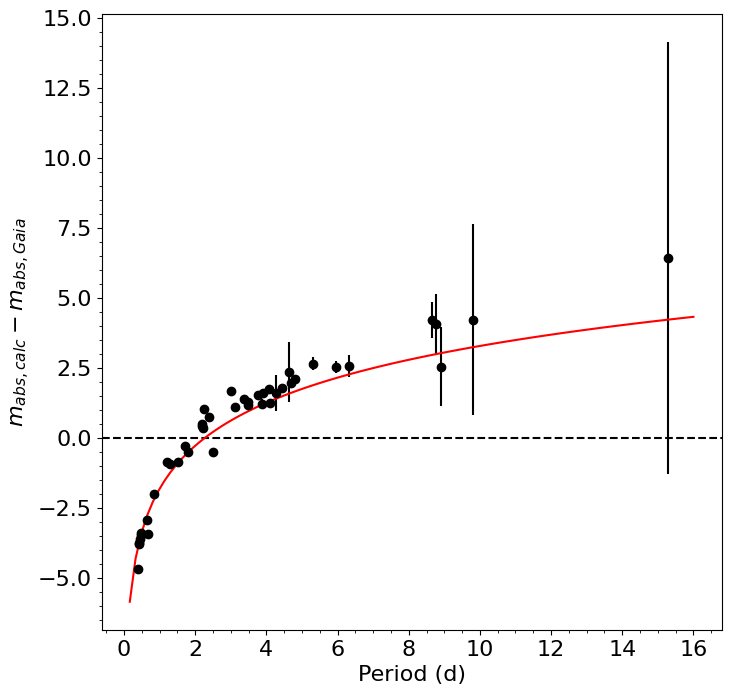

In [30]:
fig, ax1 = plt.subplots(figsize=(8,8))

ax1.errorbar(
    df['Period'],
    df['Calc_Mag'] - df['expected_mag'],
    xerr = df['P Error'],
    yerr = df['Calc_Mag_err'],
    fmt = 'o',
    color = 'black'
)

ax1.axhline(0, color='black', linestyle='--')

def log_model(x, a, b):
    return a * np.log2(x) + b

popt, pcov = curve_fit(
    log_model,
    df['Period'],
    df['Calc_Mag'] - df['expected_mag'],
    sigma=df['Calc_Mag_err'],
    absolute_sigma=True
)

a, b = popt
a_err, b_err = np.sqrt(np.diag(pcov))
print(f"Fit Result: y = ({a:.3f} +/- {a_err:.3f}) * log2(x) + ({b:.3f} +/- {b_err:.3f})")

x_fit = np.linspace(0, 16, 100)
y_fit = log_model(x_fit, a, b)
ax1.plot(x_fit, y_fit, 'r-', label=f'Log Fit: $a={a:.2f}$')

ax1.minorticks_on()
ax1.set_xlabel('Period (d)')
ax1.set_ylabel('$m_{abs, calc} - m_{abs, Gaia}$')

plt.show()

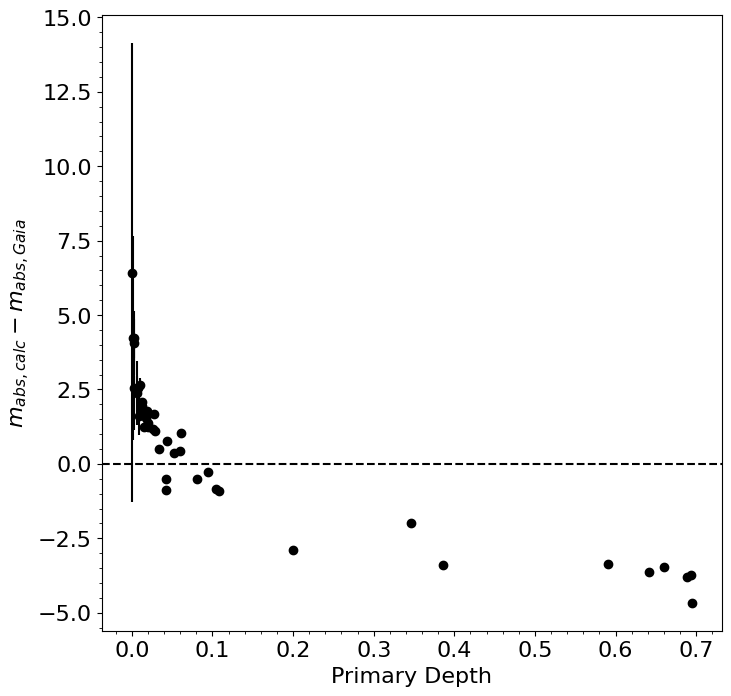

In [31]:
fig, ax1 = plt.subplots(figsize=(8,8))

ax1.errorbar(
    (df['Width1'] + df['Width2']) / (2 * df['Period']),
    df['Calc_Mag'] - df['expected_mag'],
    xerr = df['depth_err'],
    yerr = df['Calc_Mag_err'],
    fmt = 'o',
    color = 'black'
)

ax1.axhline(0, color='black', linestyle='--')

ax1.minorticks_on()
ax1.set_xlabel('Primary Depth')
ax1.set_ylabel('$m_{abs, calc} - m_{abs, Gaia}$')

plt.show()

Bias: -0.010 (+0.008 / -0.013)


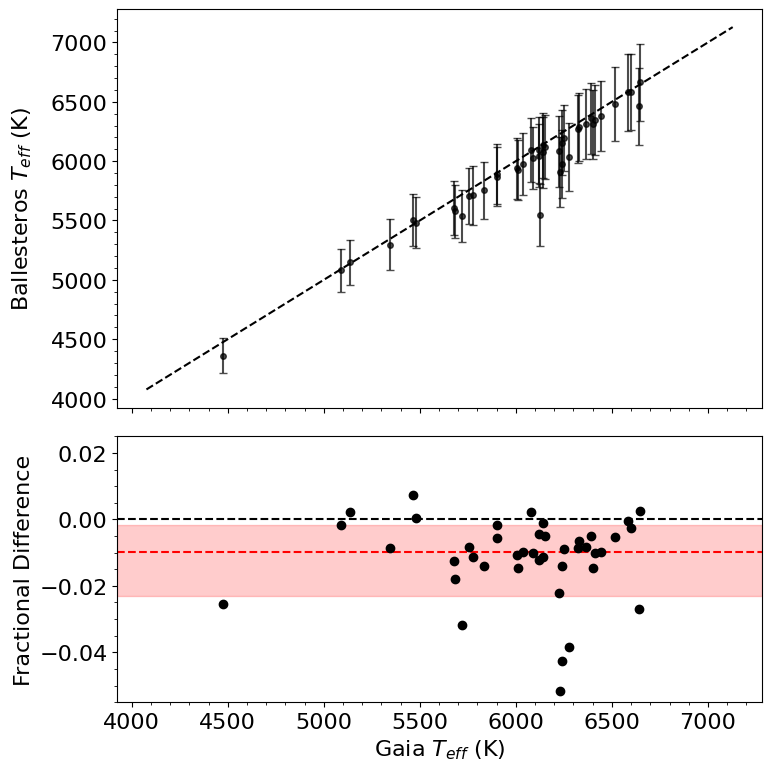

In [32]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, gridspec_kw={'height_ratios': [3,2]})
fig.subplots_adjust(hspace=0.00)

ax1.errorbar(
    x=df['Gaia3_T'],
    y=df['Ballesteros T'],
    yerr=df['Ballesteros T_err'],
    fmt='o',            # 'o' creates a scatter plot (points), rather than a line
    markersize=4,       # Adjust point size
    capsize=3,           # Adds horizontal 'caps' to the error bars
    color='black',
    ecolor='black',      # Color of the error bars
    alpha=0.7,          # Transparency to help see overlapping points
)

lims = [
    np.min([ax1.get_xlim(), ax1.get_ylim()]),  # Get the lowest value on either axis
    np.max([ax1.get_xlim(), ax1.get_ylim()]),  # Get the highest value on either axis
]

ax1.plot(lims, lims, color='black', linestyle='--', alpha=1, zorder=0)
ax1.set_ylabel(r'Ballesteros $T_{eff}$ (K)')
ax1.minorticks_on()
# ax1.set_aspect('equal')

temp_diff = df['Ballesteros T'] - df['Gaia3_T']
ax2.errorbar(
    df['Gaia3_T'],
    temp_diff / df['Gaia3_T'],
    # yerr=df['calc_d_err'],
    fmt='o',
    color='black',
    ecolor='black',
    alpha=1
)

ax2.axhline(0, color='black', linestyle='--')
ax2.axhline(np.median(temp_diff / df['Gaia3_T']), color='red', linestyle='--')
ax2.set_ylabel('Fractional Difference')
ax2.set_xlabel(r'Gaia $T_{eff}$ (K)')
ax2.minorticks_on()
ax2.set_ylim(-0.055, 0.025)

# Stats
p16, p50, p84 = np.percentile(temp_diff / df['Gaia3_T'], [16, 50, 84])
ax2.axhspan(p16, p84, color='red', alpha=0.2, label='68% Confidence')
print(f"Bias: {p50:.3f} (+{p84-p50:.3f} / -{p50-p16:.3f})")

fig.align_ylabels([ax1, ax2])
fig.tight_layout()
plt.show()

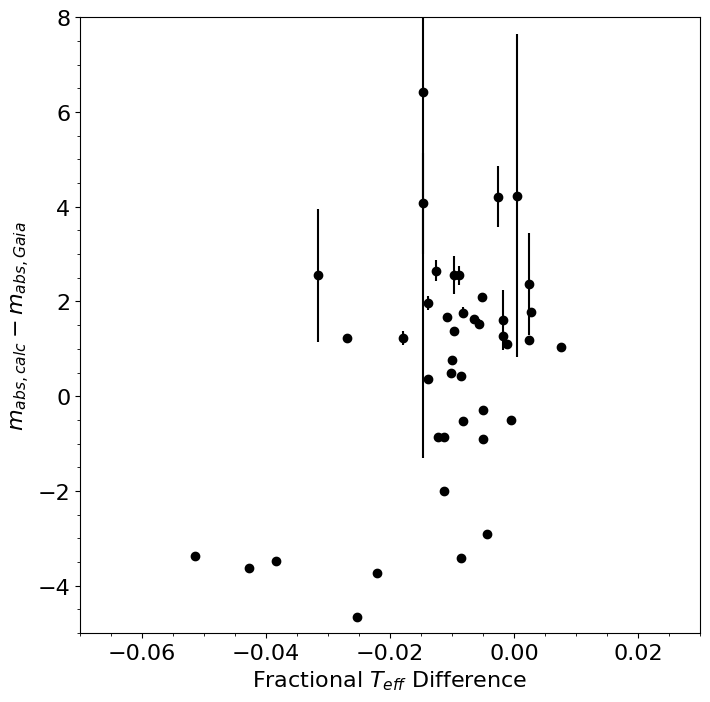

In [33]:
fig, ax1 = plt.subplots(figsize=(8,8))

ax1.errorbar(
    (df['Ballesteros T'] - df['Gaia3_T'])/df['Gaia3_T'],
    df['Calc_Mag'] - df['expected_mag'],
    # xerr = df['Ballesteros T_err']/df['Gaia3_T'],
    yerr = df['Calc_Mag_err'],
    fmt = 'o',
    color = 'black'
)

ax1.minorticks_on()
ax1.set_xlabel('Fractional $T_{eff}$ Difference')
ax1.set_ylabel('$m_{abs, calc} - m_{abs, Gaia}$')
ax1.set_ylim(-5, 8)
ax1.set_xlim(-0.07, 0.03)

plt.show()

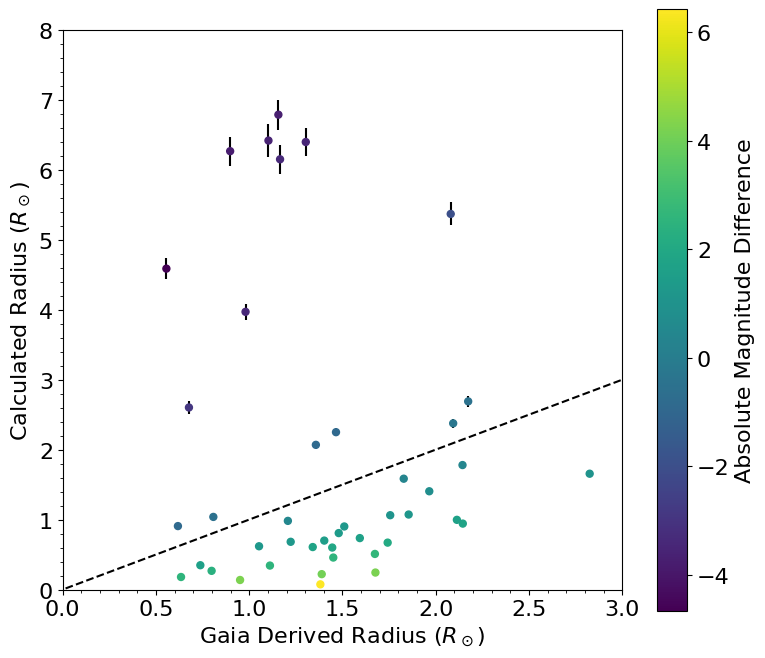

In [34]:
gaia_L = 10**(-(df['expected_mag'] - 4.74)/2.5) * c.L_sun/2
gaia_R = np.sqrt(gaia_L / (4 * np.pi * c.sigma_sb * df['Gaia3_T']**4)) / c.R_sun
our_R = df_lum['R1'] / c.R_sun
our_R_err = df_lum['R1_err'] / c.R_sun

fig, ax1 = plt.subplots(figsize=(8,8))

sc = ax1.scatter(
    gaia_R,
    our_R,
    c = df['Calc_Mag'] - df['expected_mag'],
    s=25,
    zorder=3
)

lims = [
    np.min([ax1.get_xlim(), ax1.get_ylim()]),  # Get the lowest value on either axis
    np.max([ax1.get_xlim(), ax1.get_ylim()]),  # Get the highest value on either axis
]

ax1.plot(lims, lims, color='black', linestyle='--', alpha=1, zorder=0)

ax1.errorbar(
    gaia_R,
    our_R,
    # xerr = df['Ballesteros T_err']/df['Gaia3_T'],
    yerr = our_R_err,
    fmt = 'none',
    color = 'black',
    zorder=2
)

cbar = fig.colorbar(sc, shrink=0.8)
cbar.set_label(r'Absolute Magnitude Difference')

ax1.minorticks_on()
ax1.set_xlabel(r'Gaia Derived Radius ($R_\odot$)')
ax1.set_ylabel(r'Calculated Radius ($R_\odot$)')

ax1.set_xlim(0, 3)
ax1.set_ylim(0, 8)
ax1.set_box_aspect(1)

fig.tight_layout()

plt.show()

Fit Result: y = 10 ** [(0.1398 +/- 0.0001) * x + (0.3361 +/- 0.0002)]


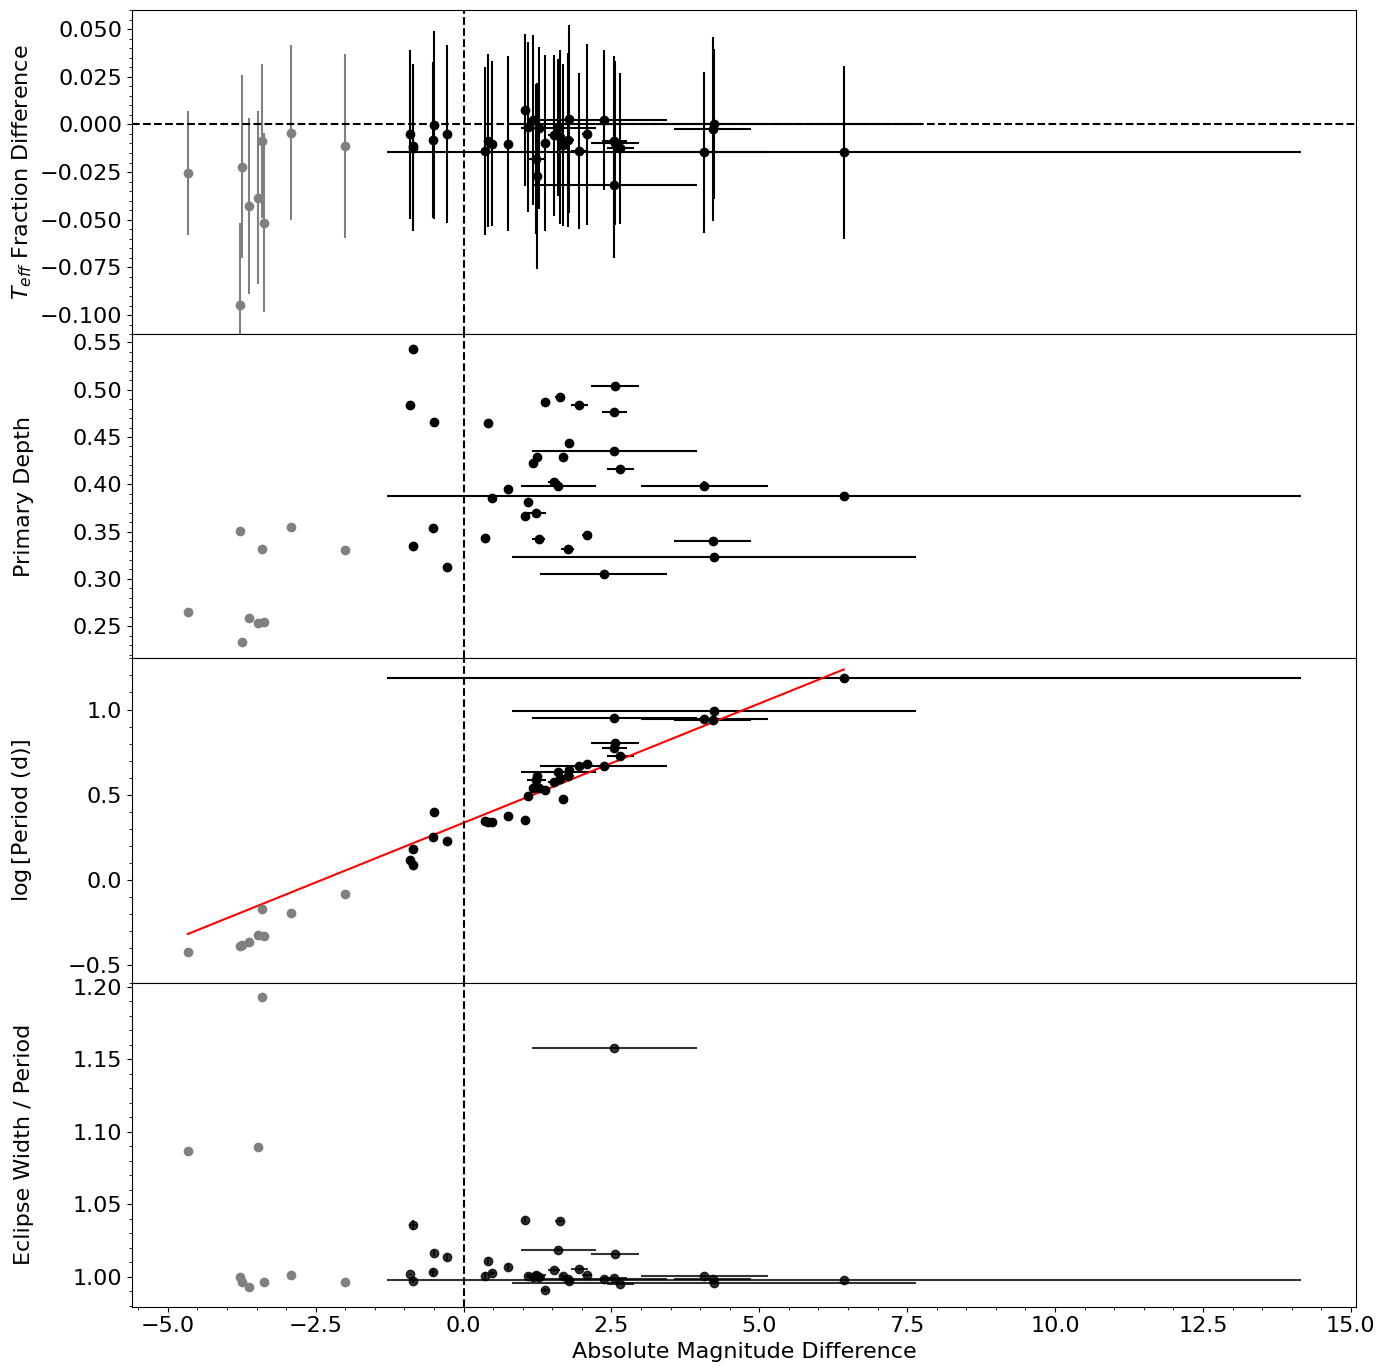

In [35]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 14), sharex=True, gridspec_kw={'height_ratios': [1,1,1,1]})

clean_diff = clean['Calc_Mag'] - clean['expected_mag']
outlier_diff = outliers['Calc_Mag'] - outliers['expected_mag']
clean_err = clean['Calc_Mag_err']
outlier_err = outliers['Calc_Mag_err']

# Temperature difference (ax1)

ax1.errorbar(
    clean_diff,
    (clean['Ballesteros T'] - clean['Gaia3_T']) / clean['Gaia3_T'],
    xerr = clean_err,
    yerr = clean['Ballesteros T_err'] / clean['Gaia3_T'],
    fmt='o',
    color='black',
    ecolor='black',
    alpha=1
)

ax1.errorbar(
    outlier_diff,
    (outliers['Ballesteros T'] - outliers['Gaia3_T']) / outliers['Gaia3_T'],
    xerr = outlier_err,
    yerr = outliers['Ballesteros T_err'] / outliers['Gaia3_T'],
    fmt='o',
    color='grey',
    ecolor='grey',
    alpha=1
)

ax1.axhline(0, color='black', linestyle='--')
ax1.axvline(0, color='black', linestyle='--')
ax1.set_ylabel(r'$T_{eff}$ Fraction Difference')
ax1.minorticks_on()
ax1.set_ylim(-0.11, 0.06)

# Depth relation (ax2)

ax2.errorbar(
    clean_diff,
    clean['depth'],
    xerr = clean_err,
    yerr = clean['depth_err'],
    fmt='o',
    color='black',
    ecolor='black',
    alpha=1
)

ax2.errorbar(
    outlier_diff,
    outliers['depth'],
    xerr = outlier_err,
    yerr = outliers['depth_err'],
    fmt='o',
    color='grey',
    ecolor='grey',
    alpha=1
)

ax2.set_ylabel(r'Primary Depth')
ax2.minorticks_on()
ax2.axvline(0, color='black', linestyle='--')

# Period relation (ax3)

clean_period = np.log10(clean['Period'])
outlier_period = np.log10(outliers['Period'])

ax3.errorbar(
    clean_diff,
    clean_period,
    xerr = clean_err,
    # yerr = clean['P Error'],
    fmt='o',
    color='black',
    ecolor='black',
    alpha=1
)

ax3.errorbar(
    outlier_diff,
    outlier_period,
    xerr = outlier_err,
    # yerr = outliers['P Error'],
    fmt='o',
    color='grey',
    ecolor='grey',
    alpha=1
)

def exp_func(x, A, B):
    return 10**(A * x + B)

popt, pcov = curve_fit(exp_func, clean_diff, clean['Period'], sigma=clean['P Error'], absolute_sigma=True)
x_fine = np.linspace((df['Calc_Mag'] - df['expected_mag']).min(), (df['Calc_Mag'] - df['expected_mag']).max(), 100)
y_fine = popt[0] * x_fine + popt[1]
ax3.plot(x_fine, y_fine, 'r-')

a, b = popt
a_err, b_err = np.sqrt(np.diag(pcov))
print(f"Fit Result: y = 10 ** [({a:.4f} +/- {a_err:.4f}) * x + ({b:.4f} +/- {b_err:.4f})]")

ax3.set_ylabel(r'$\log$[Period (d)]')
ax3.minorticks_on()
ax3.axvline(0, color='black', linestyle='--')
ax3.set_ylim(-0.6, 1.3)
# ax3.set_yscale('log')

# Width relations (ax4)

width_clean = (clean['Width1'] + clean['Width2']) / (2 * clean['Period'])
width_clean_error = np.sqrt(((clean['D1 Error']**2 + clean['D2 Error']**2) / (clean['Width1'] + clean['Width2'])**2) + (clean['P Error'] / (clean['Width1'] + clean['Width2']))**2) * width_clean

ax4.errorbar(
    clean_diff,
    (clean['Width1'] + clean['Width2']) / (2 * clean['Width1']),
    xerr = clean_err,
    yerr = width_clean_error,
    fmt='o',
    color='black',
    ecolor='black',
    alpha=0.8
)

ax4.errorbar(
    outlier_diff,
    (outliers['Width1'] + outliers['Width2']) / (2 * outliers['Width1']),
    xerr = outlier_err,
    # yerr = outliers['P Error'],
    fmt='o',
    color='grey',
    ecolor='grey',
    alpha=1
)

ax4.set_ylabel(r'Eclipse Width / Period')
ax4.minorticks_on()
ax4.axvline(0, color='black', linestyle='--')
# ax4.set_ylim(0.0002, 1.5)

ax4.set_xlabel(r'Absolute Magnitude Difference')
fig.align_ylabels([ax1, ax2, ax3, ax4])

fig.tight_layout()
fig.subplots_adjust(hspace=0.00)

plt.show()

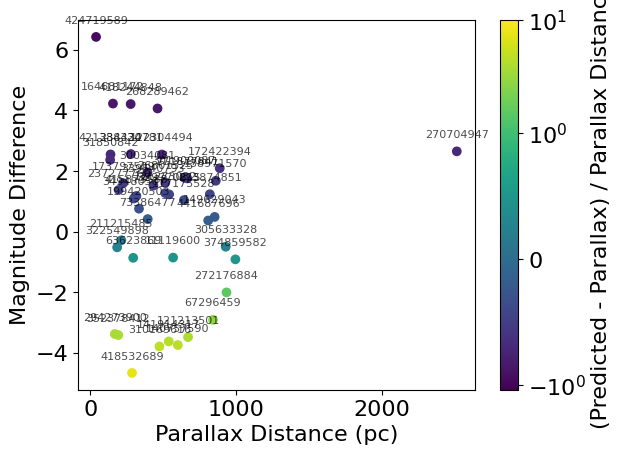

0.5575349013824594
-0.4190756562722583


In [24]:
plt.scatter(df['Dist'], df['diff'], c=((df['calc_d'] - df['Dist'])/df['Dist']), norm=colors.SymLogNorm(linthresh=1, linscale=1, 
                                           vmin=-1.1, vmax=10))

cbar = plt.colorbar()
cbar.ax.set_ylabel('(Predicted - Parallax) / Parallax Distance')
plt.xlabel('Parallax Distance (pc)')
plt.ylabel('Magnitude Difference')

for i, row in df.iterrows():
    plt.annotate(
        row['Target'],                      # The text to display
        (row['Dist'], row['diff']),         # Coordinates of the point
        textcoords="offset points",         # How to position the text
        xytext=(0, 10),                     # Distance from text to point (x,y)
        ha='center',                        # Horizontal alignment
        fontsize=8,                         # Smaller font for readability
        alpha=0.7                           # Slight transparency
    )

# plt.ylim(-5, 6)
plt.show()

print(((df['calc_d'] - df['Dist'])/df['Dist']).mean())
print(((df['calc_d'] - df['Dist'])/df['Dist']).median())

In [ ]:
plt.scatter(df['Dist'], df['diff'], c=(df['Period']))
cbar = plt.colorbar()
cbar.ax.set_ylabel('Period (d)')
plt.xlabel('Parallax Distance (pc)')
plt.ylabel('Magnitude Difference')

for i, row in df.iterrows():
    plt.annotate(
        row['Target'],                      # The text to display
        (row['Dist'], row['diff']),         # Coordinates of the point
        textcoords="offset points",         # How to position the text
        xytext=(0, 10),                     # Distance from text to point (x,y)
        ha='center',                        # Horizontal alignment
        fontsize=8,                         # Smaller font for readability
        alpha=0.7                           # Slight transparency
    )

plt.show()

In [ ]:
plt.scatter(df['Dist'], df['diff'], c=(df['Ballesteros T']))
cbar = plt.colorbar()
cbar.ax.set_ylabel('Temp (K)')
plt.xlabel('Parallax Distance (pc)')
plt.ylabel('Magnitude Difference')
plt.show()

In [ ]:
plt.scatter(df['Dist'][df['depth'] <= 0.5], df['diff'][df['depth'] <= 0.5], c=(df['depth'][df['depth'] <= 0.5]))
cbar = plt.colorbar()
cbar.ax.set_ylabel('Depth')
plt.xlabel('Parallax Distance (pc)')
plt.ylabel('Magnitude Difference')

for i, row in df[df['depth'] < 0.5].iterrows():
    plt.annotate(
        row['Target'],                      # The text to display
        (row['Dist'], row['diff']),         # Coordinates of the point
        textcoords="offset points",         # How to position the text
        xytext=(0, 10),                     # Distance from text to point (x,y)
        ha='center',                        # Horizontal alignment
        fontsize=8,                         # Smaller font for readability
        alpha=0.7                           # Slight transparency
    )

plt.show()